### 1. 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### 2. 한글 깨짐 방지 설정

In [2]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

### 3. iris 데이터셋 불러오기

In [3]:
iris = load_iris()

X = iris.data
feature_names = iris.feature_names

print("사용할 입력 변수:")
print(feature_names)

print("\n입력 데이터 크기:", X.shape)

사용할 입력 변수:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

입력 데이터 크기: (150, 4)


### 4. 데이터프레임 구성

In [4]:
df = pd.DataFrame(X, columns=feature_names)

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 5. 데이터 구조 확인

### 6. 데이터 분포 확인

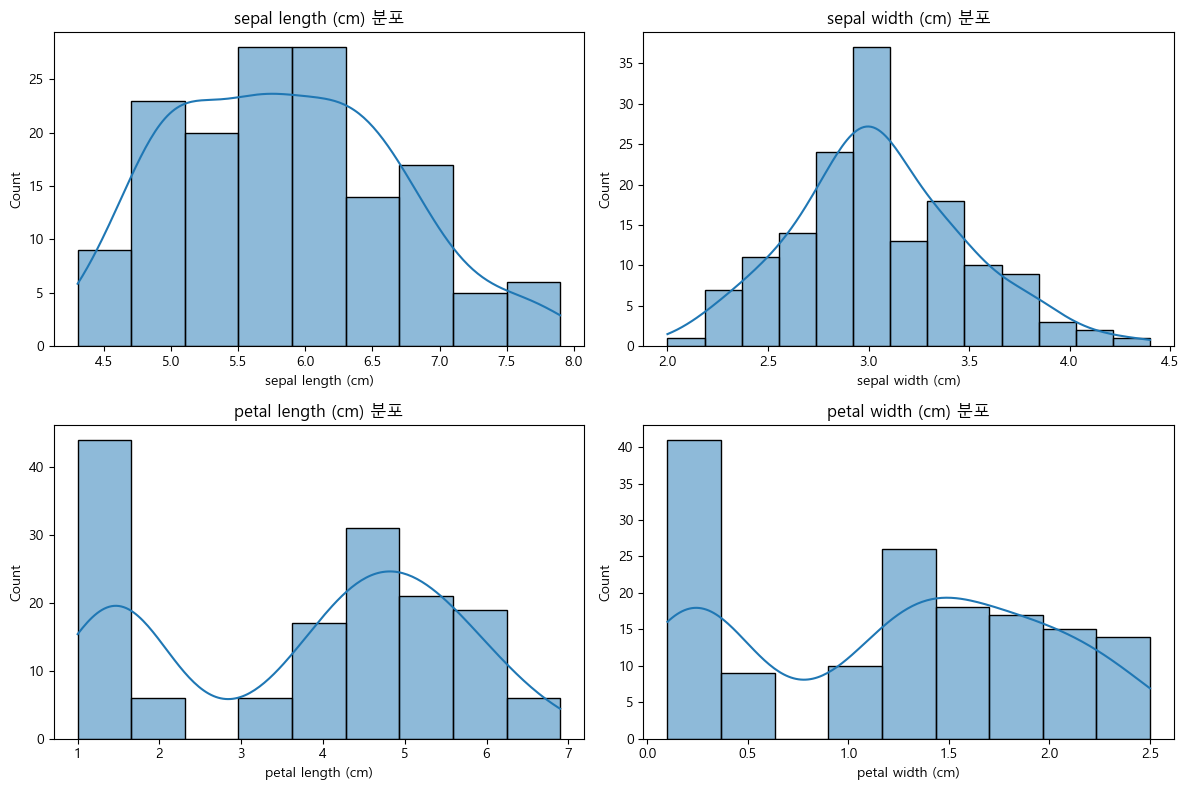

In [5]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"{col} 분포")

plt.tight_layout()

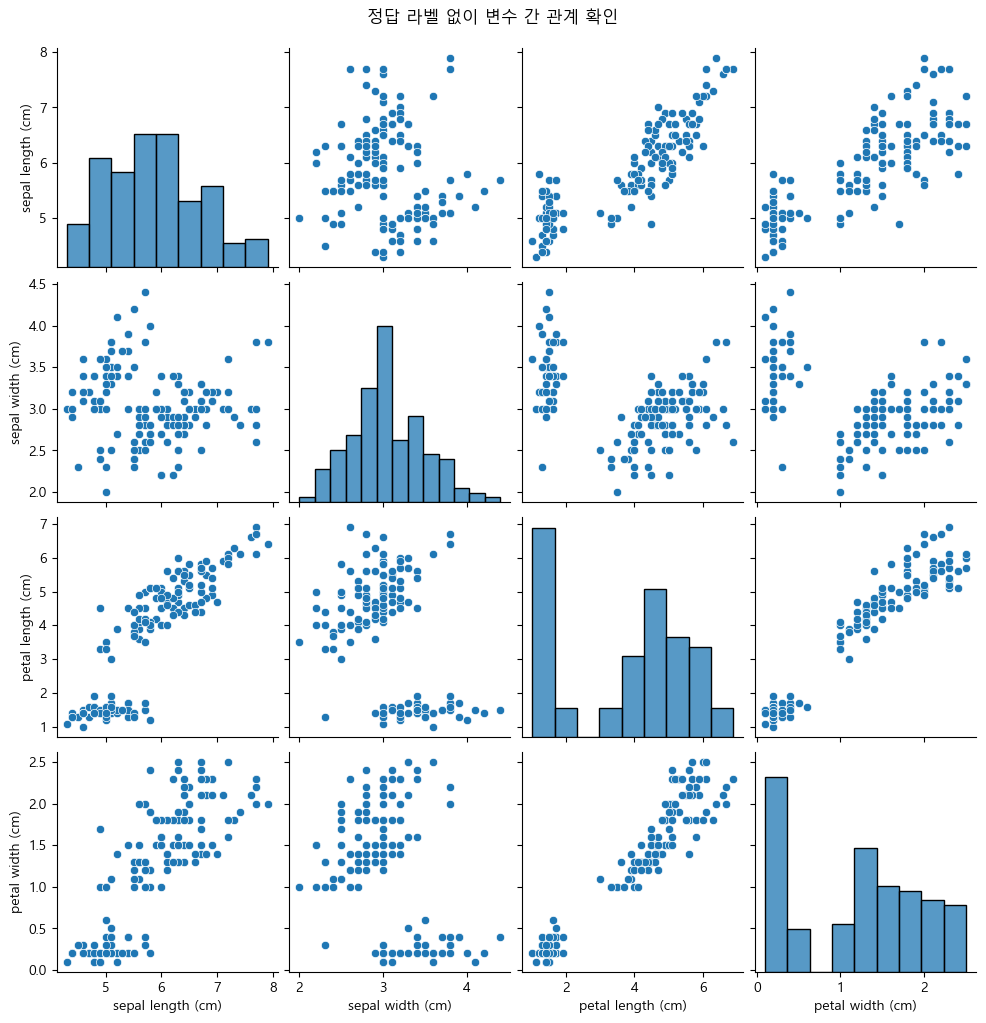

In [6]:
sns.pairplot(df, diag_kind="hist")
plt.suptitle("정답 라벨 없이 변수 간 관계 확인", y=1.02)
plt.show()

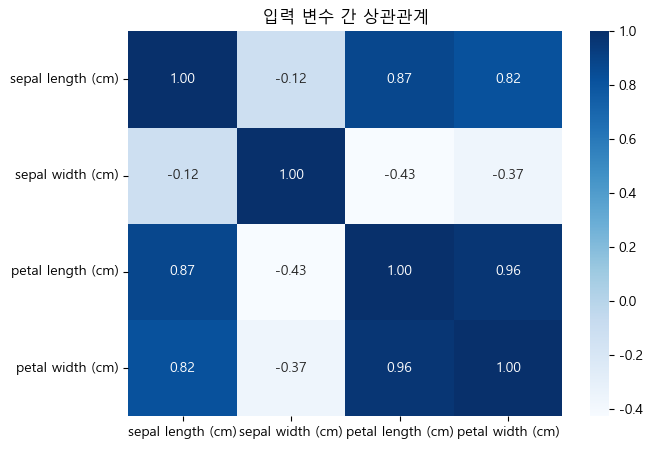

In [7]:
corr = df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("입력 변수 간 상관관계")
plt.show()

### 데이터 스케일링

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("스케일링 후 데이터:")

스케일링 후 데이터:


In [9]:
print("스케일링 후 데이터:")
display(scaled_df.head())

print("\n스케일링 후 평균:")
display(scaled_df.mean().round(3))

print("\n스케일링 후 표준편차:")
display(scaled_df.std().round(3))

스케일링 후 데이터:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444



스케일링 후 평균:


sepal length (cm)   -0.0
sepal width (cm)    -0.0
petal length (cm)   -0.0
petal width (cm)    -0.0
dtype: float64


스케일링 후 표준편차:


sepal length (cm)    1.003
sepal width (cm)     1.003
petal length (cm)    1.003
petal width (cm)     1.003
dtype: float64

### Elbow 계산

In [10]:
inertias = []

K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias
})

display(elbow_df)

C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

,K,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


### 실루엣 점수 계산

In [11]:
silhouette_results = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_temp)
    
    silhouette_results.append({
        "K": k,
        "Silhouette_Score": sil
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)

C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

,K,Silhouette_Score
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079
5,7,0.320197
6,8,0.338692
7,9,0.342360
8,10,0.351793


### 실루엣 시각화

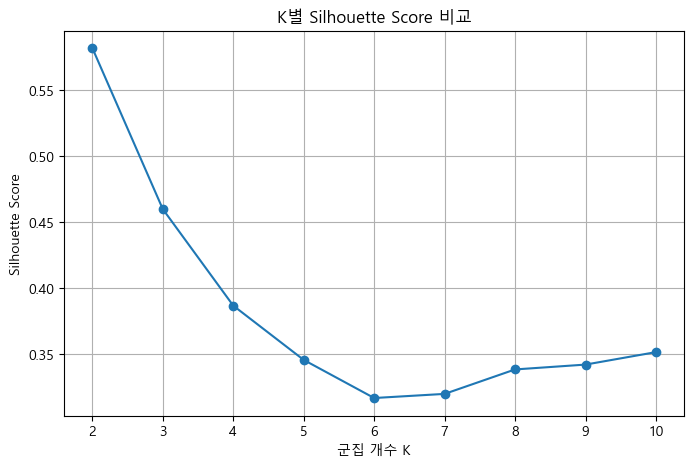

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("군집 개수 K")
plt.ylabel("Silhouette Score")
plt.title("K별 Silhouette Score 비교")
plt.xticks(silhouette_df["K"])
plt.grid(True)
plt.show()

### 최적 K

In [13]:
best_k = int(
    silhouette_df.loc[
        silhouette_df["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_score = silhouette_df["Silhouette_Score"].max()

print("Silhouette Score 기준 최적 K:", best_k)
print("최고 Silhouette Score:", round(best_score, 3))

selected_k = best_k

print("최종 선택 K:", selected_k)

Silhouette Score 기준 최적 K: 2
최고 Silhouette Score: 0.582
최종 선택 K: 2


### 모델 사용

In [14]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_df = df.copy()
cluster_df["cluster"] = cluster_labels

display(cluster_df.head())

C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
